#📌 **Extracción**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/Mau20021/TelecomX_LATAM_2/main/TelecomX_Data_L.csv')
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7039,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7040,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7041,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   objec

#**Eliminación de Columnas Irrelevantes**

Los identificadores no sirven para el modelo, por esta razón los eliminaremos.

In [8]:
df = df.drop(columns=["customerID"])
df

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7039,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7040,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7041,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#**Encoding (Variables Categóricas)**

In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded = df_encoded.dropna()

df_encoded

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65.60,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.90,542.40,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.90,280.85,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.00,1237.85,True,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.90,267.40,True,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,13,55.15,742.90,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
7039,0,22,85.10,1873.70,True,True,True,False,True,False,...,False,False,False,True,False,False,True,False,True,False
7040,0,2,50.30,92.75,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
7041,0,67,67.85,4627.65,False,True,True,True,True,False,...,False,False,False,True,False,True,False,False,False,True


#**Proporción de Cancelación**

In [11]:
df_encoded.columns

Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
       'account.Charges.Total', 'Churn_Yes', 'customer.gender_Male',
       'customer.Partner_Yes', 'customer.Dependents_Yes',
       'phone.PhoneService_Yes', 'phone.MultipleLines_No phone service',
       'phone.MultipleLines_Yes', 'internet.InternetService_Fiber optic',
       'internet.InternetService_No',
       'internet.OnlineSecurity_No internet service',
       'internet.OnlineSecurity_Yes',
       'internet.OnlineBackup_No internet service',
       'internet.OnlineBackup_Yes',
       'internet.DeviceProtection_No internet service',
       'internet.DeviceProtection_Yes',
       'internet.TechSupport_No internet service', 'internet.TechSupport_Yes',
       'internet.StreamingTV_No internet service', 'internet.StreamingTV_Yes',
       'internet.StreamingMovies_No internet service',
       'internet.StreamingMovies_Yes', 'account.Contract_One year',
       'account.Contract_Two year', 'account.Paperle

In [10]:
df_encoded["Churn_Yes"].value_counts(normalize=True) * 100

,proportion
Churn_Yes,
False,73.421502
True,26.578498


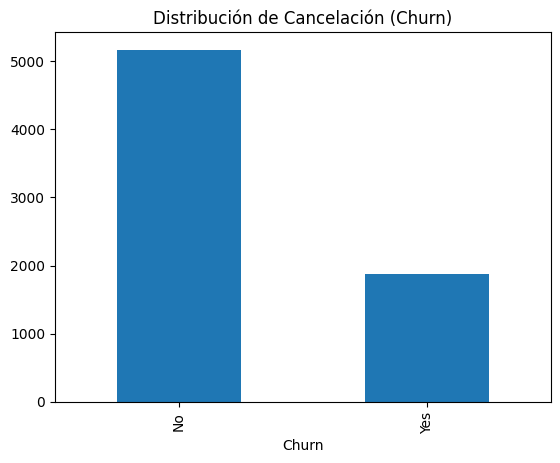

In [12]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribución de Cancelación (Churn)")
plt.show()

Distribución de Churn
Permanencia: 73.4%

Cancelación: 26.6%

Nota de análisis: Se observa un desbalanceo de clases esperado para la industria de telecomunicaciones. Con una tasa de fuga del 26.6%, el modelo debe enfocarse en no ignorar a la clase minoritaria. Se recomienda el uso de SMOTE para equilibrar los datos y evitar que el modelo se sesgue hacia los clientes que permanecen.

#**Balanceo de Clases**

In [13]:
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

#**Normalización**

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#**Análisis de Correlación**

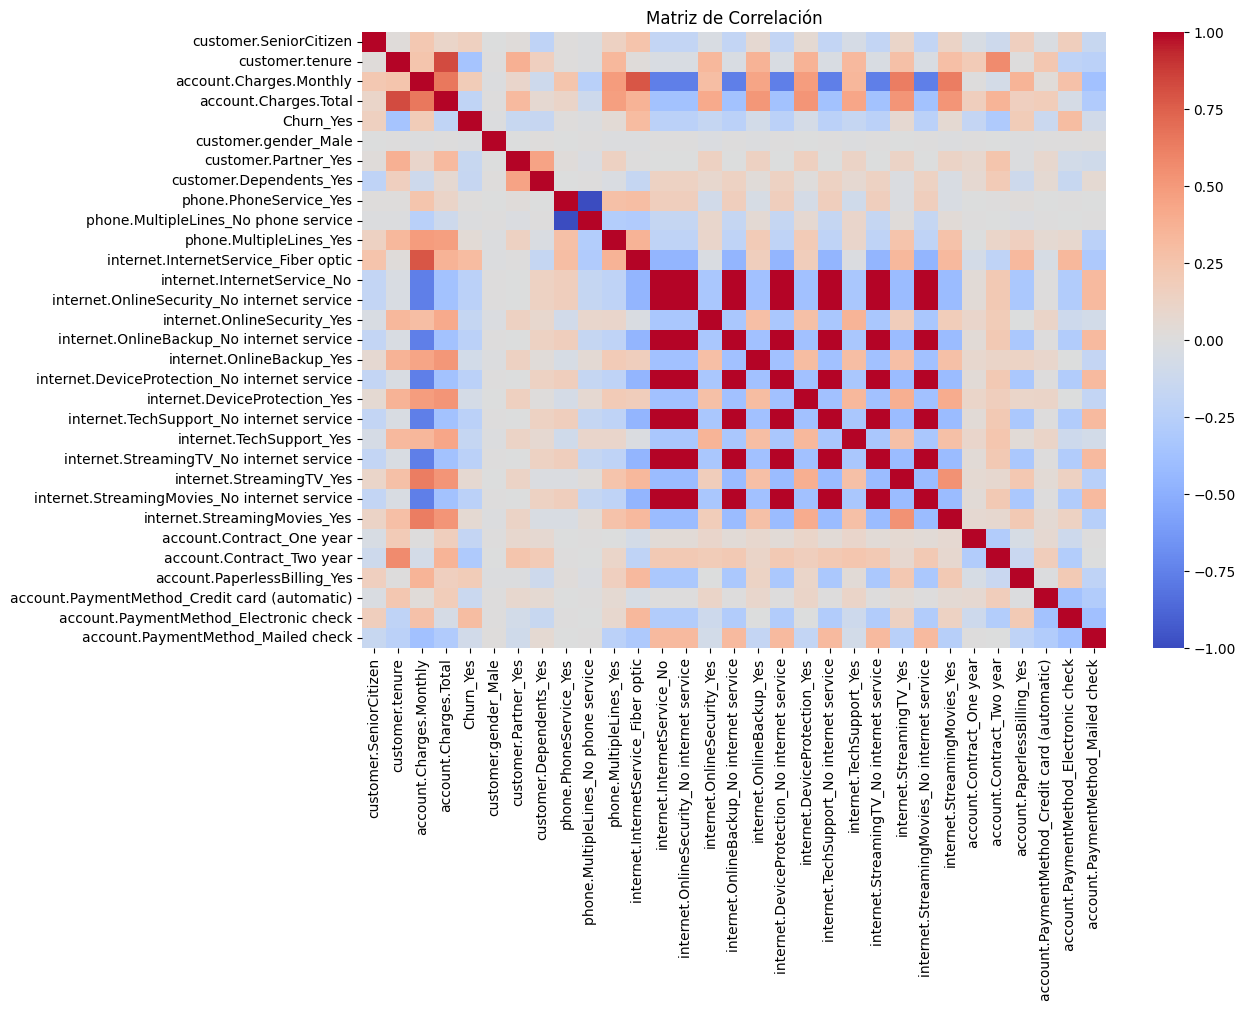

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(df_encoded.corr(), cmap="coolwarm")

plt.title("Matriz de Correlación")
plt.show()

In [16]:
df_encoded.corr()["Churn_Yes"].sort_values(ascending=False)

,Churn_Yes
Churn_Yes,1.000000
internet.InternetService_Fiber optic,0.307463
account.PaymentMethod_Electronic check,0.301455
account.Charges.Monthly,0.192858
account.PaperlessBilling_Yes,0.191454
customer.SeniorCitizen,0.150541
internet.StreamingTV_Yes,0.063254
internet.StreamingMovies_Yes,0.060860
phone.MultipleLines_Yes,0.040033
phone.PhoneService_Yes,0.011691


Análisis de Correlación con Churn
Las variables muestran relaciones claras que servirán como predictores clave:

Principales impulsores del Churn (Correlación Positiva): El uso de Fibra óptica (0.31) y el pago con Cheque Electrónico (0.30) son los factores más asociados a la cancelación. También influyen los Cargos Mensuales altos y la Facturación sin papel.

Principales factores de Retención (Correlación Negativa): La antigüedad (tenure) (-0.35) y los contratos a dos años (-0.30) son los protectores más fuertes. A mayor tiempo de contrato o permanencia, menor es la probabilidad de fuga.

Variables irrelevantes: El género (-0.008) no tiene prácticamente ninguna relación con la cancelación, por lo que no aportará valor predictivo al modelo.

#**Análisis Dirigido**

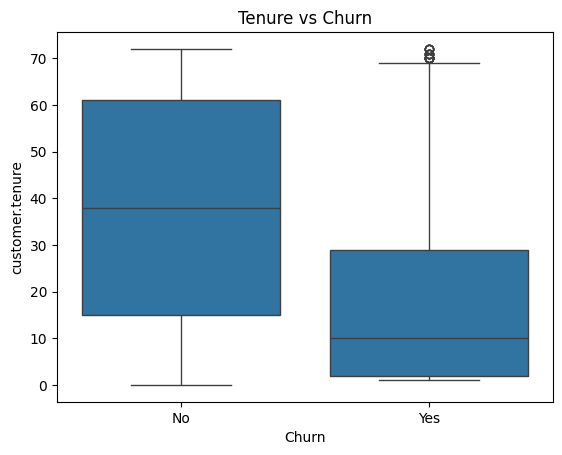

In [17]:
sns.boxplot(x="Churn", y="customer.tenure", data=df)

plt.title("Tenure vs Churn")
plt.show()

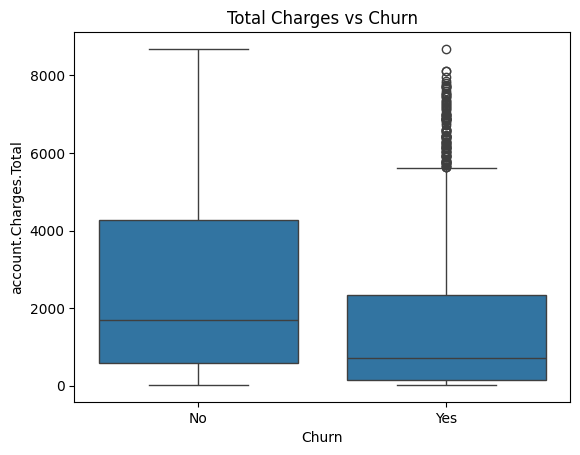

In [18]:
sns.boxplot(x="Churn", y="account.Charges.Total", data=df)

plt.title("Total Charges vs Churn")
plt.show()

#**Separación de Datos**

In [19]:
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Modelo 1 — Regresión Logística**

In [20]:
modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Modelo 2 — Random Forest**

In [21]:
modelo_rf = RandomForestClassifier()

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

**Evaluación de Modelos**

**Regresión Logística**

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.7974413646055437
              precision    recall  f1-score   support

       False       0.84      0.89      0.87      1033
        True       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407

[[919 114]
 [171 203]]


**Random Forest**

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7810945273631841
              precision    recall  f1-score   support

       False       0.82      0.90      0.86      1033
        True       0.62      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407

[[927 106]
 [202 172]]


Evaluación de Modelos: Regresión Logística vs. Random Forest
Al comparar ambos modelos, observamos lo siguiente:

Regresión Logística (Ganador actual): Obtuvo una mejor Accuracy (79.7%) y, lo más importante, un mejor Recall para la clase True (0.54). Esto significa que detecta al 54% de los clientes que realmente van a cancelar.

Random Forest: Aunque es un modelo más complejo, tuvo un desempeño ligeramente inferior en este caso (Accuracy 78.1%). Su Recall para la clase True (0.46) es más bajo, lo que indica que deja pasar a más clientes en riesgo de fuga (Falsos Negativos).

Punto Crítico (Falsos Negativos): La matriz de confusión de la Regresión Logística muestra 171 clientes que el modelo no detectó como posibles fugas, mientras que Random Forest falló en 202. Para el negocio, cada "fuga" no detectada es una pérdida de dinero.

¿Por qué la Regresión Logística ganó esta ronda?
Probablemente porque no aplicaste StandardScaler a los datos antes de entrenar. La Regresión Logística es muy sensible a la escala, pero al tener variables ya codificadas y quizás rangos similares en algunas, logró un mejor ajuste inicial que el Random Forest sin tunear.

#**Importancia de Variables**

In [25]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importancias.head(10)

,0
account.Charges.Total,0.195366
customer.tenure,0.171535
account.Charges.Monthly,0.164888
internet.InternetService_Fiber optic,0.036356
account.PaymentMethod_Electronic check,0.035177
account.Contract_Two year,0.032435
customer.gender_Male,0.027596
account.PaperlessBilling_Yes,0.025902
internet.OnlineSecurity_Yes,0.025685
customer.Partner_Yes,0.023729


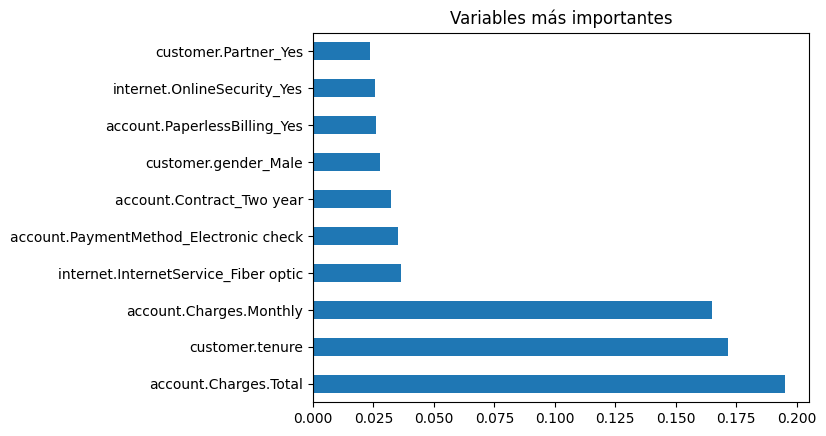

In [26]:
importancias.head(10).plot(kind="barh")

plt.title("Variables más importantes")
plt.show()

Interpretación de la Importancia de las Variables
El modelo identifica tres factores críticos que dominan la decisión de cancelación, muy por encima del resto:

Factores Financieros y de Lealtad: El gasto acumulado (Charges.Total), el tiempo de permanencia (tenure) y el cargo mensual (Charges.Monthly) representan más del 50% de la importancia del modelo. Esto sugiere que el comportamiento histórico y el costo del servicio son los principales motores del Churn.

Tecnología y Pagos: La Fibra Óptica y el Cheque Electrónico aparecen nuevamente como variables de alto impacto, confirmando lo visto en la matriz de correlación.

Baja Relevancia de Perfiles: Variables como el género o si el cliente tiene pareja tienen una importancia mínima, lo que refuerza la idea de que la cancelación es una decisión basada en el servicio y el costo, no en la demografía del cliente.

#**Conclusión**

Para reducir la cancelación en Telecom X, la estrategia debe centrarse en:

Fidelización Temprana: Dado que tenure es clave, crear incentivos para clientes nuevos en sus primeros meses.

Revisión de Fibra Óptica: Investigar por qué los clientes con este servicio se van más (¿problemas técnicos o precio?).

Migración de Contratos: Incentivar el paso de contratos mensuales a contratos de dos años, que según el modelo, es un fuerte retenedor.